# Medicare+ — Prescription Handwriting OCR

## Data Preparation

**Google Colab Requirements:** Runtime > Change runtime type > GPU (T4) is recommended.

### Dataset

We use [`mamun1113/doctors-handwritten-prescription-bd-dataset`](https://www.kaggle.com/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset) — ~4,700 cropped images of single drug names handwritten by doctors, with the printed name as label.

## 1. Install dependencies

In [41]:
!pip install -q kaggle pandas scikit-learn matplotlib sentencepiece pillow 'transformers>=4.44,<5' 'datasets>=2.20' 'accelerate>=0.33' 'evaluate>=0.4' 'jiwer>=3 '


In [42]:
from google.colab import files, drive
from pathlib import Path
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict, Image as HFImage
import subprocess
import shutil


### Setup the Model Constant Values

In [43]:
PROJECT_ROOT = "/content/drive/MyDrive/medicare_plus_ocr"
DATA_ROOT = f"{PROJECT_ROOT}/data"
KAGGLE_ROOT = "/root/.kaggle"
KAGGLE_DATASET = "mamun1113/doctors-handwritten-prescription-bd-dataset"
RAW_DIR = f"{DATA_ROOT}/raw"

TRAINING_DIR = f"{DATA_ROOT}/raw/Training"


## 2. Mount Google Drive

In [44]:
def _setup_google_drive():
    try:
        drive.mount("/content/drive")
        os.makedirs(DATA_ROOT, exist_ok=True)
    except Exception as e:
        raise RuntimeError(f"Failed to set up Google Drive: {e}")


_setup_google_drive()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Authenticate to Kaggle Account

In [45]:
# def setup_kaggle_credentials(source_path: str):
#   os.makedirs('/root/.kaggle', exist_ok=True)
#   if not os.path.exists('/root/.kaggle/kaggle.json'):
#       print('Upload your kaggle.json file:')
#       uploaded = files.upload()
#       for fname in uploaded:
#           os.rename(fname, '/root/.kaggle/kaggle.json')
#   os.chmod('/root/.kaggle/kaggle.json', 0o600)
#   print('Kaggle credentials in place.')

# setup_kaggle_credentials("./kaggle.json")


## 4. Import the Dataset

In [46]:
# def download_kaggle_dataset(dataset_name: str, download_path: str):
#     os.makedirs(download_path, exist_ok=True)

#     if not os.listdir(download_path):
#             !kaggle datasets download -d {dataset_name} -p {download_path} --unzip
#     else:
#         FileExistsError("Dataset already downloaded — skipping.")

#     !ls -lah {download_path} | head -20

# download_kaggle_dataset(KAGGLE_DATASET, RAW_DIR)


## 5. Discover the dataset structure

In [47]:
def _list_csv_files_in_directory(directory: str, extensions: set = {".csv"}):
    raw = Path(directory)
    if not raw.exists():
        raise FileNotFoundError(f"Directory '{directory}' does not exist.")
    files = []

    for ext in extensions:
        files.extend(raw.rglob(f"*{ext}"))

    csv_files = [str(file) for file in files]

    print(f"CSV Files > {len(csv_files)}")

    return csv_files

def _list_image_files_in_directory(
    directory: str, extensions: set = {".png", ".jpg", ".jpeg"}
):
    raw = Path(directory)
    if not raw.exists():
        raise FileNotFoundError(f"Directory '{directory}' Does Not Exist.")

    image_files = [p for p in raw.rglob("*") if p.suffix.lower() in extensions]
    print(f"Image Files > {len(image_files)}")
    return image_files


csv_file = _list_csv_files_in_directory(TRAINING_DIR)
image_file = _list_image_files_in_directory(TRAINING_DIR)


CSV Files > 1
Image Files > 3120


## 6. Load Dataset

In [48]:
def _normalize_label(s: str) -> str:
    return str(s).strip().lower()


def _load_files(**kwargs) -> pd.DataFrame:
    records = []
    csv_loaded = False

    for csv_file in kwargs.get('csv_path', ''):
      try:
          df = pd.read_csv(csv_file)
          cols_lower = {c.lower(): c for c in df.columns}

          img_col = next((cols_lower[k] for k in cols_lower if "image" in k or "file" in k or "name" in k), None)
          print(img_col)

          label_col = next((cols_lower[k] for k in cols_lower if "medicine" in k or "label" in k or "word" in k or "text" in k), None)
          print(label_col)


          if img_col and label_col and img_col != label_col:
              print(f"Using CSV: {kwargs.get('csv_path', '')}\n  image col: {img_col}\n  label col: {label_col}")
              path_lookup = {p.name: p for p in kwargs.get("image_path", "")}

              for _, row in df.iterrows():
                img_name = str(row[img_col]).strip()
                label = _normalize_label(row[label_col])
                p = (path_lookup.get(img_name) or path_lookup.get(img_name + ".png") or path_lookup.get(img_name + ".jpg"))

                if p is not None and label:
                    records.append({"image_path": str(p), "label": label})

              csv_loaded = True
              break

      except Exception as e:
          print(f"Error: {e}")

    if not csv_loaded:
        print("No usable CSV — falling back to folder names for labels.")
        try:
            if not kwargs.get("image_path", ""):
                raise FileNotFoundError("No image files found in the directory.")
            for p in kwargs.get("image_path", ""):
                records.append(
                    {"image_path": str(p), "label": _normalize_label(p.parent.name)}
                )

        except Exception as e:
            raise RuntimeError(f"Error: {e}")

    df_all = (
        pd.DataFrame(records)
        .drop_duplicates(subset=["image_path"])
        .reset_index(drop=True)
    )
    print(df_all)

    return df_all


def _display_dataset_info(df: pd.DataFrame):
    print(f"Total samples: {len(df)}")
    print(f'Unique labels: {df["label"].nunique()}')
    df.head()

df_all = _load_files(csv_path=csv_file, image_path=image_file)

_display_dataset_info(df_all)


IMAGE
MEDICINE_NAME
Using CSV: ['/content/drive/MyDrive/medicare_plus_ocr/data/raw/Training/training_labels.csv']
  image col: IMAGE
  label col: MEDICINE_NAME
                                             image_path    label
0     /content/drive/MyDrive/medicare_plus_ocr/data/...    aceta
1     /content/drive/MyDrive/medicare_plus_ocr/data/...    aceta
2     /content/drive/MyDrive/medicare_plus_ocr/data/...    aceta
3     /content/drive/MyDrive/medicare_plus_ocr/data/...    aceta
4     /content/drive/MyDrive/medicare_plus_ocr/data/...    aceta
...                                                 ...      ...
3115  /content/drive/MyDrive/medicare_plus_ocr/data/...  zithrin
3116  /content/drive/MyDrive/medicare_plus_ocr/data/...  zithrin
3117  /content/drive/MyDrive/medicare_plus_ocr/data/...  zithrin
3118  /content/drive/MyDrive/medicare_plus_ocr/data/...  zithrin
3119  /content/drive/MyDrive/medicare_plus_ocr/data/...  zithrin

[3120 rows x 2 columns]
Total samples: 3120
Unique labels: 

## 7. Dataset Exploration

Top 20 most common drug names:

label
aceta         40
ace           40
alatrol       40
amodis        40
atrizin       40
axodin        40
azithrocin    40
azyth         40
az            40
bacaid        40
backtone      40
baclofen      40
baclon        40
bacmax        40
beklo         40
bicozin       40
canazole      40
candinil      40
cetisoft      40
conaz         40
Name: count, dtype: int64
Labels with only 1 sample: 0

Labels with >= 5 samples: 78



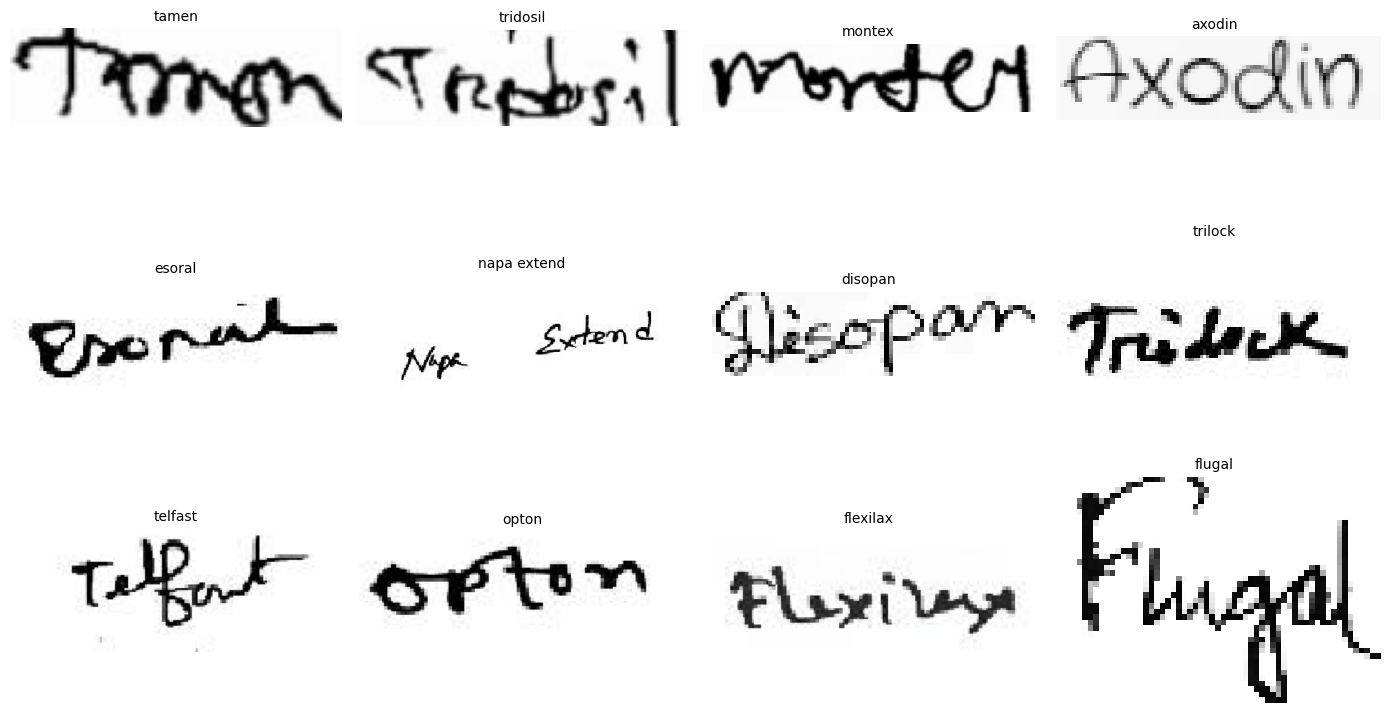

In [49]:
def _display_dataset_explore(df: pd.DataFrame):
    label_counts = df["label"].value_counts()

    print("Top 20 most common drug names:\n")
    print(df["label"].value_counts().head(20))

    print(f"Labels with only 1 sample: {(label_counts == 1).sum()}\n")
    print(f"Labels with >= 5 samples: {(label_counts >= 5).sum()}\n")

    sample = df.sample(min(12, len(df)), random_state=42).reset_index(drop=True)
    fig, axes = plt.subplots(3, 4, figsize=(14, 8))

    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["label"], fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


_display_dataset_explore(df_all)


## 8. Dataframe Train / Validation / Test split (8:1:1 Ratio)

In [50]:
def _split_dataset(local_df: pd.DataFrame, random_state=42):
    counts: pd.Series = local_df["label"].value_counts()
    print(f"Total labels: {len(counts)}")
    common = local_df[local_df["label"].isin(counts[counts >= 2].index)].copy()
    print(f"Common labels: {len(common)}")
    rare = local_df[local_df["label"].isin(counts[counts < 2].index)].copy()
    print(f"Rare labels: {len(rare)}")

    train_data_common, test_common = train_test_split(
        common,
        test_size=0.10,
        random_state=random_state,
        stratify=common["label"] if common["label"].nunique() > 1 else None,
    )

    train_common, val_common = train_test_split(
        train_data_common,
        test_size=0.111,
        random_state=random_state,
        stratify=(
            train_data_common["label"]
            if train_data_common["label"].nunique() > 1
            else None
        ),
    )

    train_df = (
        pd.concat([train_common, rare], ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    val_df = val_common.reset_index(drop=True)
    test_df = test_common.reset_index(drop=True)

    print(f"Train Data: {len(train_df)}")
    print(f"Validation Data: {len(val_df)}")
    print(f"Test Data: {len(test_df)}")

    return [train_df, val_df, test_df]


df = _split_dataset(df_all)


Total labels: 78
Common labels: 3120
Rare labels: 0
Train Data: 2496
Validation Data: 312
Test Data: 312


## 9. Save as DatasetDict

In [51]:
def to_hf(df: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(
        df[["image_path", "label"]].rename(columns={"image_path": "image"})
    )
    return ds.cast_column("image", HFImage())


def _prepare_and_save_datasets(
    train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame
):
    splits = DatasetDict(
        {
            "train": to_hf(train_df),
            "validation": to_hf(val_df),
            "test": to_hf(test_df),
        }
    )

    PREPARED_DIR = f"{DATA_ROOT}/prepared"
    splits.save_to_disk(PREPARED_DIR)
    print(f"Saved DatasetDict to: {PREPARED_DIR}")
    print(splits)


_prepare_and_save_datasets(df[0], df[1], df[2])


Saving the dataset (0/1 shards):   0%|          | 0/2496 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/312 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/312 [00:00<?, ? examples/s]

Saved DatasetDict to: /content/drive/MyDrive/medicare_plus_ocr/data/prepared
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2496
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 312
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 312
    })
})


# Complete Preprocessing Phase

## 10. Initialize the Training Libraries

In [52]:
import torch
from datasets import load_from_disk
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset
import evaluate
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator
import shutil

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")


PyTorch: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


## 11. Mount Drive & Load Prepared Dataset

In [53]:
# PROJECT_ROOT = "/content/drive/MyDrive/medicare_plus_ocr"
PREPARED_DIR = f"{PROJECT_ROOT}/data/prepared"
MODEL_OUT_DIR = f"{PROJECT_ROOT}/models/trocr-prescription"
LOG_DIR = f"{PROJECT_ROOT}/logs"

BASE_MODEL = "microsoft/trocr-base-handwritten"
MAX_TARGET_LENGTH = 32

NUM_EPOCHS = 10
BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 5e-5

os.makedirs(MODEL_OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

splits = load_from_disk(PREPARED_DIR)
print(splits)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2496
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 312
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 312
    })
})


## 12. Load TrOCR processor + model

In [54]:
processor = TrOCRProcessor.from_pretrained(BASE_MODEL)
model = VisionEncoderDecoderModel.from_pretrained(BASE_MODEL)


def _prepare_processor_and_model(max_tar_len: int):

    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.eos_token_id = processor.tokenizer.sep_token_id
    model.config.vocab_size = model.config.decoder.vocab_size

    model.config.max_length = max_tar_len
    model.config.num_beams = 4
    model.config.early_stopping = True
    model.config.no_repeat_ngram_size = 3
    model.config.length_penalty = 2.0


_prepare_processor_and_model(MAX_TARGET_LENGTH)


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 13. Dataset Wrapper

In [55]:
class TrOCRDataset(Dataset):
    def __init__(self, hf_split, processor, max_target_length=MAX_TARGET_LENGTH):
        self.split = hf_split
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        row = self.split[idx]
        image = row["image"].convert("RGB")
        text = row["label"]
        pixel_values = self.processor(image, return_tensors="pt").pixel_values[0]
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
        ).input_ids
        labels = [
            t if t != self.processor.tokenizer.pad_token_id else -100 for t in labels
        ]
        return {"pixel_values": pixel_values, "labels": torch.tensor(labels)}


train_ds = TrOCRDataset(splits["train"], processor)
val_ds = TrOCRDataset(splits["validation"], processor)

print(f"train samples: {len(train_ds)}")
print(f"val   samples: {len(val_ds)}")


train samples: 2496
val   samples: 312


## 14. CER Metric for Evaluation

In [56]:
cer_metric = evaluate.load("cer")

def compute_metrics(eval_pred):
  pred_ids, label_ids = eval_pred
  label_ids_clean = [[t for t in seq if t != -100] for seq in label_ids]
  label_str = processor.batch_decode(label_ids_clean, skip_special_tokens=True)
  pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
  cer = cer_metric.compute(predictions=pred_str, references=label_str)
  return {"cer": cer}


## 15. Configure Training

In [57]:
training_args = Seq2SeqTrainingArguments(
    output_dir=f"{LOG_DIR}/checkpoints",
    overwrite_output_dir=True,
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    fp16=torch.cuda.is_available(),
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_EPOCHS,
    warmup_steps=200,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=processor.feature_extractor,
    compute_metrics=compute_metrics,
    data_collator=default_data_collator,
)


/usr/local/lib/python3.12/dist-packages/transformers/models/trocr/processing_trocr.py:139: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(
/tmp/ipykernel_241/3417135487.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


## 16. Training Process

In [58]:
trainer.train()


Epoch,Training Loss,Validation Loss,Cer
1,0.405900,0.663988,0.545040
2,0.280400,0.186075,0.504049
3,0.052800,0.151255,0.418522
4,0.019700,0.106946,0.460526
5,0.023700,0.088295,0.410931
6,0.010100,0.080970,0.405364
7,0.000100,0.062176,0.405364
8,0.000000,0.055708,0.404858
9,0.000000,0.058212,0.407389
10,0.000000,0.057977,0.407389


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 32, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


TrainOutput(global_step=3120, training_loss=0.1467358073777737, metrics={'train_runtime': 2312.1865, 'train_samples_per_second': 10.795, 'train_steps_per_second': 1.349, 'total_flos': 1.867719836725936e+19, 'train_loss': 0.1467358073777737, 'epoch': 10.0})

## 17. Save Final Model to Drive

In [59]:
trainer.save_model(MODEL_OUT_DIR)
processor.save_pretrained(MODEL_OUT_DIR)
print(f'Model saved to: {MODEL_OUT_DIR}')
!ls -lah {MODEL_OUT_DIR}


Model saved to: /content/drive/MyDrive/medicare_plus_ocr/models/trocr-prescription
total 1.3G
-rw------- 1 root root 1.7K May 23 11:20 config.json
-rw------- 1 root root  273 May 23 11:20 generation_config.json
-rw------- 1 root root 446K May 23 11:21 merges.txt
-rw------- 1 root root 1.3G May 23 11:21 model.safetensors
-rw------- 1 root root  390 May 23 11:21 preprocessor_config.json
-rw------- 1 root root  957 May 23 11:21 special_tokens_map.json
-rw------- 1 root root 1.3K May 23 11:21 tokenizer_config.json
-rw------- 1 root root 3.4M May 23 11:21 tokenizer.json
-rw------- 1 root root 5.9K May 23 11:21 training_args.bin
-rw------- 1 root root 780K May 23 11:21 vocab.json


## 18. Zip the Model and Offer a Download Link

In [60]:
ZIP_PATH = "/content/trocr-prescription.zip"
shutil.make_archive(ZIP_PATH.replace(".zip", ""), "zip", MODEL_OUT_DIR)
print(f"Zip size: {os.path.getsize(ZIP_PATH) / 1e6:.1f} MB")
files.download(ZIP_PATH)


Zip size: 1238.9 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Complete Training Phase

## 19. Install the Evaluation Libraries

In [61]:
import os, torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from datasets import load_from_disk
from PIL import Image as PILImage
import pandas as pd
from tqdm.auto import tqdm
import evaluate
import matplotlib.pyplot as plt
import random
import json


## 20. Mount Drive, load model & test split

In [62]:
MODEL_DIR = f"{PROJECT_ROOT}/models/trocr-prescription"
PREPARED_DIR = f"{PROJECT_ROOT}/data/prepared"
BASE_MODEL = "microsoft/trocr-base-handwritten"

BATCH_SIZE = 16
MAX_LEN = 32

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

processor = TrOCRProcessor.from_pretrained(MODEL_DIR)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR).to(device).eval()

splits = load_from_disk(PREPARED_DIR)
test_split = splits["test"]
print(f"Test samples: {len(test_split)}")


Device: cuda
Test samples: 312


## 21. Generate Predictions on the Test Set

In [63]:
def predict_batch(images, num_beams=4, num_return_sequences=1):
    pixel_values = processor(images, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_length=MAX_LEN,
            num_beams=num_beams,
            num_return_sequences=num_return_sequences,
            early_stopping=True,
        )
    texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
    return texts


preds, refs = [], []
for i in tqdm(range(0, len(test_split), BATCH_SIZE)):
    rows = test_split[i : i + BATCH_SIZE]
    images = [img.convert("RGB") for img in rows["image"]]
    labels = [str(l).strip().lower() for l in rows["label"]]
    out = predict_batch(images, num_beams=4, num_return_sequences=1)
    preds.extend([t.strip().lower() for t in out])
    refs.extend(labels)

results_df = pd.DataFrame({"reference": refs, "prediction": preds})
results_df.head(10)


  0%|          | 0/20 [00:00<?, ?it/s]

,reference,prediction
0,trilock,trock
1,monas,mon
2,dinafex,dfffof
3,provair,provair
4,montair,t
5,diflu,dlu
6,exium,ex
7,axodin,axin
8,tridosil,tros
9,romycin,romy


## 22. CER and WER on Test Set

In [64]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

cer = cer_metric.compute(predictions=preds, references=refs)
wer = wer_metric.compute(predictions=preds, references=refs)
print(f"Test CER: {cer:.4f}  (lower is better)")
print(f"Test WER: {wer:.4f}")


Test CER: 0.4165  (lower is better)
Test WER: 0.8576


## 23. Exact-Match Accuracy

In [65]:
exact = (results_df["reference"] == results_df["prediction"]).mean()
print(
    f"Exact-match accuracy: {exact:.4f}  ({int(exact * len(results_df))} / {len(results_df)})"
)


Exact-match accuracy: 0.1442  (44 / 312)


## 24. Top-K Accuracy via Beam Search

In [66]:
K = 5
topk_hits = 0
topk_preds_all = []

for i in tqdm(range(0, len(test_split), BATCH_SIZE)):
    rows = test_split[i : i + BATCH_SIZE]
    images = [img.convert("RGB") for img in rows["image"]]
    labels = [str(l).strip().lower() for l in rows["label"]]
    out = predict_batch(images, num_beams=K, num_return_sequences=K)
    out = [
        [t.strip().lower() for t in out[j * K : (j + 1) * K]]
        for j in range(len(images))
    ]
    for label, candidates in zip(labels, out):
        if label in candidates:
            topk_hits += 1
        topk_preds_all.append(candidates)

print(f"Top-{K} accuracy: {topk_hits / len(test_split):.4f}")


  0%|          | 0/20 [00:00<?, ?it/s]

Top-5 accuracy: 0.2788


## 25. Most common errors

In [67]:
errors_df = results_df[results_df["reference"] != results_df["prediction"]].copy()
errors_df["pair"] = errors_df["reference"] + "  →  " + errors_df["prediction"]
print(f"Total errors: {len(errors_df)} / {len(results_df)}")
print("\nTop 20 most frequent confusion pairs:")
print(errors_df["pair"].value_counts().head(20).to_string())


Total errors: 267 / 312

Top 20 most frequent confusion pairs:
pair
trilock  →  trock         4
monas  →  mon             4
dinafex  →  dfffof        4
diflu  →  dlu             4
exium  →  ex              4
axodin  →  axin           4
flugal  →  fl             4
tridosil  →  tros         4
romycin  →  romy          4
amodis  →  amis           4
dancel  →  d              4
bicozin  →  bzin          4
telfast  →  tast          4
flexibac  →  flexac       4
renova  →  ren            4
baclon  →  blon           4
ketoral  →  ket           4
tamen  →  t               4
montene  →  monteneene    4
omastin  →  omin          4


## 26. Side-by-Side Visualization

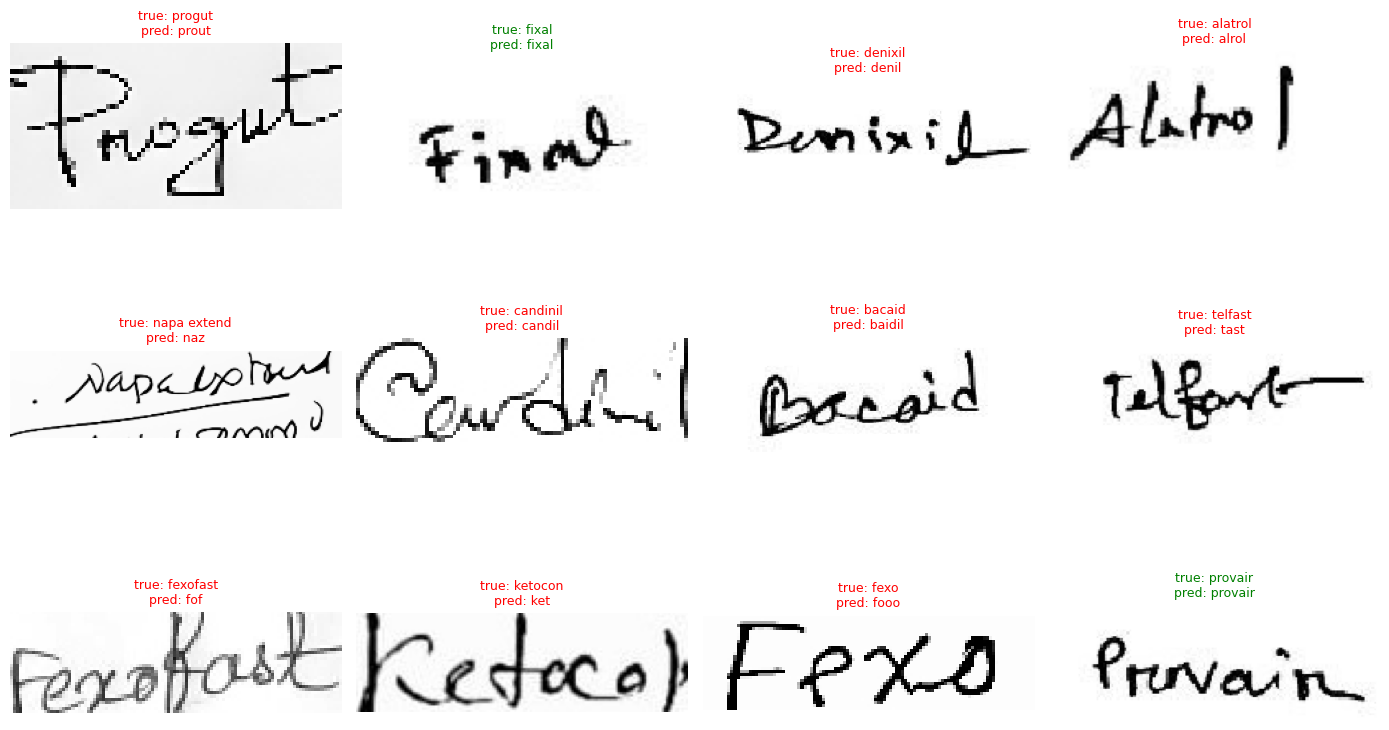

In [68]:
N_SHOW = 12

sample_idx = random.sample(range(len(test_split)), N_SHOW)
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, idx in zip(axes.ravel(), sample_idx):
    row = test_split[idx]
    img = row["image"].convert("RGB")
    label = str(row["label"]).strip().lower()
    pred = preds[idx]
    color = "green" if pred == label else "red"
    ax.imshow(img)
    ax.set_title(f"true: {label}\npred: {pred}", fontsize=9, color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 27. Before vs After — Baseline TrOCR Comparison

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/20 [00:00<?, ?it/s]

Metric              Baseline       Fine-tuned     Delta     
------------------------------------------------------------
CER (lower=better)  0.6113         0.4165         -0.1948
Exact match (acc)   0.0962         0.1442         +0.0481


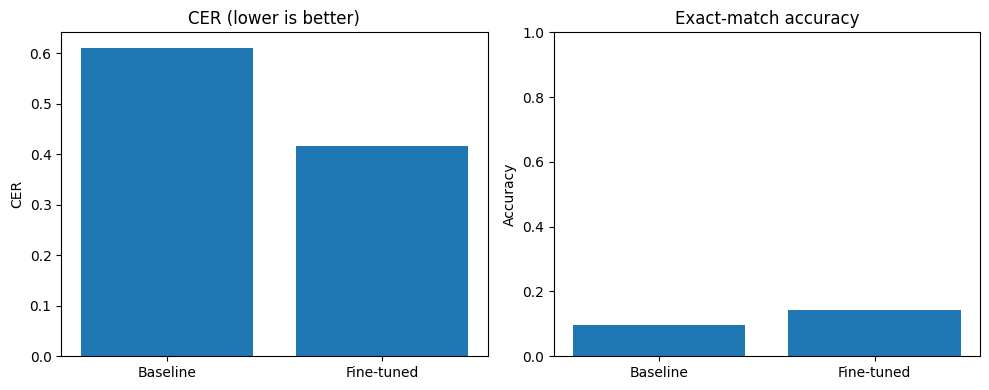

In [69]:
base_processor = TrOCRProcessor.from_pretrained(BASE_MODEL)
base_model = VisionEncoderDecoderModel.from_pretrained(BASE_MODEL).to(device).eval()


def predict_with(p, m, images):
    pixel_values = p(images, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        ids = m.generate(
            pixel_values, max_length=MAX_LEN, num_beams=4, early_stopping=True
        )
    return [t.strip().lower() for t in p.batch_decode(ids, skip_special_tokens=True)]


SAMPLE_N = min(500, len(test_split))
sample_idx = random.sample(range(len(test_split)), SAMPLE_N)

base_preds, ft_preds, gold = [], [], []
for i in tqdm(range(0, SAMPLE_N, BATCH_SIZE)):
    chunk = sample_idx[i : i + BATCH_SIZE]
    images = [test_split[j]["image"].convert("RGB") for j in chunk]
    labels = [str(test_split[j]["label"]).strip().lower() for j in chunk]
    base_preds.extend(predict_with(base_processor, base_model, images))
    ft_preds.extend(predict_with(processor, model, images))
    gold.extend(labels)

base_cer = cer_metric.compute(predictions=base_preds, references=gold)
ft_cer = cer_metric.compute(predictions=ft_preds, references=gold)
base_exact = sum(p == g for p, g in zip(base_preds, gold)) / len(gold)
ft_exact = sum(p == g for p, g in zip(ft_preds, gold)) / len(gold)

print(f'{"Metric":<20}{"Baseline":<15}{"Fine-tuned":<15}{"Delta":<10}')
print(f'{"-"*60}')
print(
    f'{"CER (lower=better)":<20}{base_cer:<15.4f}{ft_cer:<15.4f}{ft_cer - base_cer:+.4f}'
)
print(
    f'{"Exact match (acc)":<20}{base_exact:<15.4f}{ft_exact:<15.4f}{ft_exact - base_exact:+.4f}'
)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(["Baseline", "Fine-tuned"], [base_cer, ft_cer])
ax[0].set_title("CER (lower is better)")
ax[0].set_ylabel("CER")

ax[1].bar(["Baseline", "Fine-tuned"], [base_exact, ft_exact])
ax[1].set_title("Exact-match accuracy")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 28. Save Evaluation Report

In [70]:
REPORT_DIR = f"{PROJECT_ROOT}/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

results_df.to_csv(f"{REPORT_DIR}/test_predictions.csv", index=False)
summary = {
    "test_cer": cer,
    "test_wer": wer,
    "test_exact_match": exact,
    f"top_{K}_accuracy": topk_hits / len(test_split),
    "baseline_sample_cer": base_cer,
    "finetuned_sample_cer": ft_cer,
    "baseline_sample_exact": base_exact,
    "finetuned_sample_exact": ft_exact,
    "test_samples": len(test_split),
    "comparison_sample_size": SAMPLE_N,
}
with open(f"{REPORT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(f"\nSaved to: {REPORT_DIR}")


{
  "test_cer": 0.416497975708502,
  "test_wer": 0.8575949367088608,
  "test_exact_match": 0.14423076923076922,
  "top_5_accuracy": 0.27884615384615385,
  "baseline_sample_cer": 0.611336032388664,
  "finetuned_sample_cer": 0.416497975708502,
  "baseline_sample_exact": 0.09615384615384616,
  "finetuned_sample_exact": 0.14423076923076922,
  "test_samples": 312,
  "comparison_sample_size": 312
}

Saved to: /content/drive/MyDrive/medicare_plus_ocr/reports
